<a href="https://colab.research.google.com/github/paganinigor0807/tech-challenge-fase3/blob/develop/notebooks/estudo_analitico_alfabetizacao_brasil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Instalação das bibliotecas oficiais
!pip install basedosdados pandas pyarrow google-cloud-bigquery -q

import basedosdados as bd
import pandas as pd

# Autenticação na sua conta Google dentro do Colab
from google.colab import auth
auth.authenticate_user()
print("Autenticado com sucesso no Google Cloud!")

Autenticado com sucesso no Google Cloud!


In [ ]:
# Insira aqui o ID do projeto que você criou no Google Cloud:
BILLING_PROJECT_ID = "tech-challenge-fase3-506316"

import os
import basedosdados as bd
import pandas as pd

# Cria a pasta 'data' localmente para salvar os arquivos Parquet
os.makedirs("data", exist_ok=True)

# Dicionário com as 6 tabelas do dataset de Avaliação da Alfabetização
tabelas = {
    "uf": "br_inep_avaliacao_alfabetizacao.uf",
    "meta_alfabetizacao_brasil": "br_inep_avaliacao_alfabetizacao.meta_alfabetizacao_brasil",
    "meta_alfabetizacao_uf": "br_inep_avaliacao_alfabetizacao.meta_alfabetizacao_uf",
    "meta_alfabetizacao_municipio": "br_inep_avaliacao_alfabetizacao.meta_alfabetizacao_municipio",
    "municipio": "br_inep_avaliacao_alfabetizacao.municipio",
    "alunos": "br_inep_avaliacao_alfabetizacao.alunos"
}

# Consulta na nuvem e conversão para Parquet
for nome_tabela, dataset_id in tabelas.items():
    dataset_id_str = dataset_id.split('.')[0]
    tabela_id = dataset_id.split('.')[1]

    print(f"\n{'='*60}")
    print(f"☁️ Consultando na nuvem (BigQuery): {nome_tabela}")
    print(f"{'='*60}")

    try:
        # Lê a tabela direto do BigQuery usando o projeto do usuário
        df = bd.read_table(
            dataset_id=dataset_id_str,
            table_id=tabela_id,
            billing_project_id=BILLING_PROJECT_ID
        )

        # Mostra uma prévia dos dados
        display(df.head(3))
        print(f"Dimensões -> Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")

        # Salva o resultado em formato Parquet na pasta local 'data/'
        caminho_parquet = f"data/{nome_tabela}.parquet"
        df.to_parquet(caminho_parquet, index=False)
        print(f"✅ Salvo em Parquet com sucesso: {caminho_parquet}")

    except Exception as e:
        print(f"❌ Erro ao consultar a tabela {nome_tabela}: {e}")

print("\n✨ Processo em nuvem concluído com sucesso!")


☁️ Consultando na nuvem (BigQuery): uf
Downloading: 100%|██████████|


,ano,sigla_uf,serie,rede,taxa_alfabetizacao,media_portugues,proporcao_aluno_nivel_0,proporcao_aluno_nivel_1,proporcao_aluno_nivel_2,proporcao_aluno_nivel_3,proporcao_aluno_nivel_4,proporcao_aluno_nivel_5,proporcao_aluno_nivel_6,proporcao_aluno_nivel_7,proporcao_aluno_nivel_8
0,2023,AM,2,3,49.20,733.6637,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023,PB,2,2,55.23,744.8152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023,PR,2,5,73.12,757.2146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Dimensões -> Linhas: 145 | Colunas: 15
✅ Salvo em Parquet com sucesso: data/uf.parquet

☁️ Consultando na nuvem (BigQuery): meta_alfabetizacao_brasil
Downloading: 100%|██████████|


,ano,rede,taxa_alfabetizacao,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,percentual_participacao
0,2025,Pública,66.0,60.0,64.00,67.00,71.00,74.00,77.00,80.0,88.00
1,2024,Pública,59.2,59.9,63.77,67.47,70.97,74.23,77.24,80.0,87.37
2,2023,Pública,55.9,59.9,63.77,67.47,70.97,74.23,77.24,80.0,86.00


Dimensões -> Linhas: 3 | Colunas: 11
✅ Salvo em Parquet com sucesso: data/meta_alfabetizacao_brasil.parquet

☁️ Consultando na nuvem (BigQuery): meta_alfabetizacao_uf
Downloading: 100%|██████████|


...

Dimensões -> Linhas: 10704 | Colunas: 13
✅ Salvo em Parquet com sucesso: data/meta_alfabetizacao_municipio.parquet

☁️ Consultando na nuvem (BigQuery): municipio
Downloading: 100%|██████████|


,ano,id_municipio,serie,rede,taxa_alfabetizacao,media_portugues,proporcao_aluno_nivel_0,proporcao_aluno_nivel_1,proporcao_aluno_nivel_2,proporcao_aluno_nivel_3,proporcao_aluno_nivel_4,proporcao_aluno_nivel_5,proporcao_aluno_nivel_6,proporcao_aluno_nivel_7,proporcao_aluno_nivel_8
0,2023,1100031,2,3,69.10,767.8763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023,1100072,2,3,58.20,747.8918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023,1100189,2,5,69.73,762.4062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Dimensões -> Linhas: 23995 | Colunas: 15
✅ Salvo em Parquet com sucesso: data/municipio.parquet

☁️ Consultando na nuvem (BigQuery): alunos
Downloading: 100%|██████████|


,ano,id_municipio,id_escola,id_aluno,caderno,serie,rede,presenca,preenchimento_caderno,alfabetizado,proficiencia,peso_aluno
0,2023,2513703,60011396,25010199,1,2,3,0,0,0,NaN,NaN
1,2024,2403608,60010036,24028203,1,2,3,0,0,0,NaN,NaN
2,2024,3169505,60021200,31184973,1,2,3,0,0,0,NaN,NaN


Dimensões -> Linhas: 3867999 | Colunas: 12
✅ Salvo em Parquet com sucesso: data/alunos.parquet

✨ Processo em nuvem concluído com sucesso!


Explorando a tabela de Alunos:

In [ ]:
import pandas as pd

# Carrega a tabela de alunos a partir do arquivo Parquet salvo localmente
df_alunos = pd.read_parquet("data/alunos.parquet")

# Exibe as primeiras linhas da tabela para uma rápida visualização
df_alunos.head()

,ano,id_municipio,id_escola,id_aluno,caderno,serie,rede,presenca,preenchimento_caderno,alfabetizado,proficiencia,peso_aluno
0,2023,2513703,60011396,25010199,1,2,3,0,0,0,NaN,NaN
1,2024,2403608,60010036,24028203,1,2,3,0,0,0,NaN,NaN
2,2024,3169505,60021200,31184973,1,2,3,0,0,0,NaN,NaN
3,2024,3506003,60029780,35024753,1,2,3,0,0,0,NaN,NaN
4,2024,3550308,60026535,35428394,1,2,2,0,0,0,NaN,NaN


In [ ]:
# Verifica os tipos de dados, quantidade de registros e valores nulos
df_alunos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3867999 entries, 0 to 3867998
Data columns (total 12 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ano                    Int64  
 1   id_municipio           object 
 2   id_escola              object 
 3   id_aluno               object 
 4   caderno                object 
 5   serie                  object 
 6   rede                   object 
 7   presenca               object 
 8   preenchimento_caderno  object 
 9   alfabetizado           object 
 10  proficiencia           float64
 11  peso_aluno             float64
dtypes: Int64(1), float64(2), object(9)
memory usage: 357.8+ MB


In [ ]:
# Resumo estatístico inicial das colunas numéricas
display(df_alunos.describe())

,ano,proficiencia,peso_aluno
count,3867999.0,3.354661e+06,3.354661e+06
mean,2023.548232,7.483799e+02,1.148490e+00
std,0.497668,4.758598e+01,3.585160e-01
min,2023.0,5.784600e+02,9.523810e-02
25%,2023.0,7.197686e+02,1.000709e+00
50%,2024.0,7.531500e+02,1.091625e+00
75%,2024.0,7.796500e+02,1.208405e+00
max,2024.0,9.043820e+02,1.425454e+02


In [ ]:
import pandas as pd

# Carrega a tabela de alunos salva em Parquet
df_alunos = pd.read_parquet("data/alunos.parquet")

# Verifica os nomes das colunas para confirmar o nome exato da coluna de presença
print("Colunas disponíveis:", df_alunos.columns.tolist())

# Filtra apenas os registros onde a presença é 'Sim' (ajuste o nome da coluna se necessário, ex: 'presenca')
# Vamos supor que a coluna se chame 'presenca' ou 'indicador_presenca'
coluna_presenca = [c for c in df_alunos.columns if 'presenca' in c.lower()][0]

df_alunos_presentes = df_alunos[df_alunos[coluna_presenca].astype(str).str.upper().isin(['SIM', 'S', '1'])]

print(f"Total de registros originais: {len(df_alunos)}")
print(f"Total de alunos com presença 'Sim': {len(df_alunos_presentes)}")

# Visualiza as primeiras linhas da base filtrada
display(df_alunos_presentes.head())

Colunas disponíveis: ['ano', 'id_municipio', 'id_escola', 'id_aluno', 'caderno', 'serie', 'rede', 'presenca', 'preenchimento_caderno', 'alfabetizado', 'proficiencia', 'peso_aluno']
Total de registros originais: 3867999
Total de alunos com presença 'Sim': 3355846


,ano,id_municipio,id_escola,id_aluno,caderno,serie,rede,presenca,preenchimento_caderno,alfabetizado,proficiencia,peso_aluno
220,2023,5003702,60040418,50555820,1,2,3,1,0,0,NaN,NaN
255,2024,4302105,60039510,43006971,1,2,3,1,0,0,NaN,NaN
506,2023,3300704,60025977,33014504,1,2,3,1,1,1,760.476300,0.31011
507,2023,4212700,60036473,42050748,1,2,3,1,1,1,759.644703,0.40998
508,2023,4204202,60035585,42024809,1,2,2,1,1,1,795.209974,0.49537


Alunos que tem presença porem não tem proficiencia

In [ ]:
import pandas as pd

# Carrega a tabela de alunos e filtra os presentes
df_alunos = pd.read_parquet("data/alunos.parquet")
df_presentes = df_alunos[df_alunos[coluna_presenca].astype(str).str.upper().isin(['SIM', 'S', '1'])]

# Calcula a quantidade e a porcentagem de alunos presentes sem nota de proficiência
total_presentes = len(df_presentes)
sem_proficiencia = df_presentes['proficiencia'].isnull().sum()
perc_sem_proficiencia = (sem_proficiencia / total_presentes) * 100

print(f"Quantidade: {sem_proficiencia:,}")
print(f"Porcentagem: {perc_sem_proficiencia:.2f}%")

Quantidade: 1,185
Porcentagem: 0.04%


In [ ]:
# Verificando a proporção da variável alvo (alfabetizado) nos alunos presentes com presença confirmada
proporcao_alvo = df_presentes['alfabetizado'].value_counts(normalize=True) * 100
print("Proporção da Variável Alvo (Alfabetizado):")
display(proporcao_alvo)

# Verificando por ano para entender a evolução temporal
proporcao_ano = df_presentes.groupby('ano')['alfabetizado'].value_counts(normalize=True).unstack() * 100
print("\nProporção por Ano:")
display(proporcao_ano)

Proporção da Variável Alvo (Alfabetizado):


,proportion
alfabetizado,
1,59.136981
0,40.863019



Proporção por Ano:


alfabetizado,0,1
ano,,
2023,41.623876,58.376124
2024,40.245781,59.754219


In [ ]:
import numpy as np

# 1. Fazendo uma cópia de segurança e removendo os poucos alunos sem nota (os 0.04% que achamos antes)
df_modelo = df_presentes.dropna(subset=['proficiencia']).copy()

# 2. Definindo as faixas (bins) exatamente como na sua imagem
# -np.inf representa "tudo abaixo de 650" e np.inf "tudo acima de 825"
bins = [-np.inf, 650, 675, 700, 725, 750, 775, 800, 825, np.inf]

# 3. Definindo os rótulos (labels) dos níveis numéricos (onde 0 = "Abaixo de 1")
labels = [0, 1, 2, 3, 4, 5, 6, 7, 8]

# 4. Criando a nova coluna com a função pd.cut
# O parâmetro right=False indica que o limite inferior está incluso (ex: >= 650 e < 675)
df_modelo['nivel_proficiencia'] = pd.cut(
    df_modelo['proficiencia'],
    bins=bins,
    labels=labels,
    right=False
)

# 5. O pd.cut cria a coluna como "Category", vamos converter para inteiro para facilitar a modelagem
df_modelo['nivel_proficiencia'] = df_modelo['nivel_proficiencia'].astype(int)

# 6. Visualizando o resultado para conferir se bate com a regra
display(df_modelo[['id_aluno', 'proficiencia', 'nivel_proficiencia', 'alfabetizado']].sample(10, random_state=42))

,id_aluno,proficiencia,nivel_proficiencia,alfabetizado
1649884,52035407,751.150000,5,1
94603,29269802,740.290000,4,0
3622655,23009166,899.390000,8,1
1997111,50468100,787.920000,6,1
2547157,23072550,784.400530,6,1
3095727,23087473,846.575960,8,1
1659617,21055183,805.867064,7,1
1007381,27004489,713.320000,3,0
2416616,29016162,751.920000,5,1
1663183,15020772,717.880000,3,0


In [ ]:
import pandas as pd

# 1. Agrupando por ano e nível de proficiência para contar a quantidade de alunos
df_agrupado = df_modelo.groupby(['ano', 'nivel_proficiencia']).size().reset_index(name='quantidade')

# 2. Calculando o total de alunos por ano para descobrir a porcentagem
total_por_ano = df_agrupado.groupby('ano')['quantidade'].transform('sum')

# 3. Criando a coluna de porcentagem e arredondando para 2 casas decimais
df_agrupado['porcentagem (%)'] = ((df_agrupado['quantidade'] / total_por_ano) * 100).round(2)

# 4. Exibindo o resultado final de forma clara
print("Distribuição de Alunos por Nível de Proficiência (por Ano):")
display(df_agrupado)

# -------------------------------------------------------------------
# BÔNUS: Visualização em formato de tabela cruzada (Pivot Table)
# para facilitar a comparação visual entre 2023 e 2024
# -------------------------------------------------------------------
print("\nVisão Comparativa (Porcentagem % por Nível):")
tabela_comparativa = df_agrupado.pivot(index='nivel_proficiencia', columns='ano', values='porcentagem (%)')
tabela_comparativa.index.name = 'Nível SAEB'
display(tabela_comparativa)

Distribuição de Alunos por Nível de Proficiência (por Ano):


,ano,nivel_proficiencia,quantidade,porcentagem (%)
0,2023,0,47804,3.18
1,2023,1,81028,5.39
2,2023,2,130808,8.70
3,2023,3,166668,11.09
4,2023,4,294166,19.57
5,2023,5,359821,23.94
6,2023,6,240861,16.03
7,2023,7,112619,7.49
8,2023,8,69034,4.59
9,2024,0,50625,2.73



Visão Comparativa (Porcentagem % por Nível):


ano,2023,2024
Nível SAEB,,
0,3.18,2.73
1,5.39,5.01
2,8.70,8.62
3,11.09,11.09
4,19.57,18.86
5,23.94,23.95
6,16.03,17.41
7,7.49,8.21
8,4.59,4.12


In [ ]:
# 1. Calculando a variação em pontos percentuais (diferença entre 2024 e 2023)
tabela_comparativa['Variação (p.p.)'] = tabela_comparativa[2024] - tabela_comparativa[2023]

# 2. Criando uma função simples para colorir os resultados positivos e negativos
def destacar_variacao(valor):
    if pd.isna(valor):
        return ''
    elif valor > 0:
        return 'color: green; font-weight: bold'
    elif valor < 0:
        return 'color: red; font-weight: bold'
    else:
        return 'color: gray'

# 3. Aplicando o estilo visual na tabela e formatando as casas decimais
# Nota: dependendo da versão do Pandas, use .map() ou .applymap()
try:
    tabela_estilizada = tabela_comparativa.style.map(destacar_variacao, subset=['Variação (p.p.)']).format("{:.2f}")
except AttributeError:
    tabela_estilizada = tabela_comparativa.style.applymap(destacar_variacao, subset=['Variação (p.p.)']).format("{:.2f}")

# Exibindo o resultado final
display(tabela_estilizada)

ano,2023,2024,Variação (p.p.)
Nível SAEB,,,
0,3.18,2.73,-0.45
1,5.39,5.01,-0.38
2,8.70,8.62,-0.08
3,11.09,11.09,0.00
4,19.57,18.86,-0.71
5,23.94,23.95,0.01
6,16.03,17.41,1.38
7,7.49,8.21,0.72
8,4.59,4.12,-0.47


Total de registros corrigidos: 3354661 (deve voltar para ~3.3M)


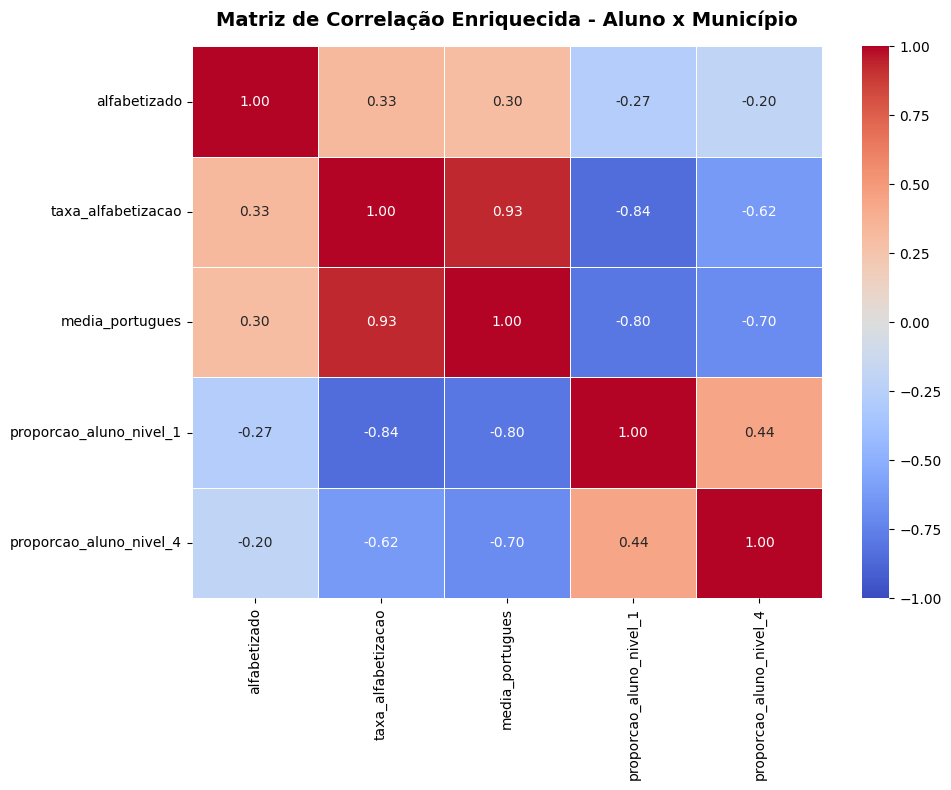

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carrega a tabela de municípios
df_municipio = pd.read_parquet("data/municipio.parquet")

# 2. Corrige o Merge usando todas as chaves granulares para evitar duplicidade
df_enriquecido = df_modelo.merge(
    df_municipio,
    on=['ano', 'id_municipio', 'rede', 'serie'],
    how='left'
)

print(f"Total de registros corrigidos: {len(df_enriquecido)} (deve voltar para ~3.3M)")

# 3. Seleciona colunas contextuais do município + a nossa variável alvo do aluno
# Continuamos deixando 'proficiencia' de fora para evitar Data Leakage
colunas_matriz = [
    'alfabetizado',           # Variável Alvo do aluno
    'taxa_alfabetizacao',     # Contexto: Taxa geral da cidade/rede
    'media_portugues',        # Contexto: Média de notas da cidade/rede
    'proporcao_aluno_nivel_1',# Contexto: % de alunos muito abaixo na cidade
    'proporcao_aluno_nivel_4' # Contexto: % de alunos na linha de corte da cidade
]

# 4. Prepara os dados (garante tipo numérico)
df_corr_enriquecida = df_enriquecido[colunas_matriz].apply(pd.to_numeric, errors='coerce')

# 5. Plota a nova Matriz de Correlação
plt.figure(figsize=(10, 8))
matriz_enriquecida = df_corr_enriquecida.corr()

sns.heatmap(
    matriz_enriquecida,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)
plt.title('Matriz de Correlação Enriquecida - Aluno x Município', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1. Dicionário padrão do IBGE para converter os 2 primeiros dígitos do município na Sigla da UF
mapa_uf = {
    '11': 'RO', '12': 'AC', '13': 'AM', '14': 'RR', '15': 'PA', '16': 'AP', '17': 'TO',
    '21': 'MA', '22': 'PI', '23': 'CE', '24': 'RN', '25': 'PB', '26': 'PE', '27': 'AL', '28': 'SE', '29': 'BA',
    '31': 'MG', '32': 'ES', '33': 'RJ', '35': 'SP',
    '41': 'PR', '42': 'SC', '43': 'RS',
    '50': 'MS', '51': 'MT', '52': 'GO', '53': 'DF'
}

# 2. Criando a coluna 'sigla_uf' na nossa base enriquecida
# Pega os 2 primeiros dígitos do id_municipio e mapeia para a sigla
df_enriquecido['id_uf'] = df_enriquecido['id_municipio'].astype(str).str[:2]
df_enriquecido['sigla_uf'] = df_enriquecido['id_uf'].map(mapa_uf)

# 3. Carrega a tabela de UF
df_uf = pd.read_parquet("data/uf.parquet")

# 4. Renomeia as métricas da tabela UF para adicionar o sufixo '_uf'
# Isso evita que o Pandas crie nomes confusos como _x e _y e mantém a clareza
colunas_renomeadas = {}
for col in df_uf.columns:
    if col not in ['ano', 'sigla_uf', 'serie', 'rede']:
        colunas_renomeadas[col] = f"{col}_uf"
df_uf = df_uf.rename(columns=colunas_renomeadas)

# 5. Faz o cruzamento final (Left Join)
df_base_final = df_enriquecido.merge(
    df_uf,
    on=['ano', 'sigla_uf', 'rede', 'serie'],
    how='left'
)

print(f"Total de registros na Base Final: {len(df_base_final)}")
print("\nVeja as novas colunas estaduais adicionadas:")
print([col for col in df_base_final.columns if '_uf' in col])

# Visualiza um exemplo das colunas de contexto (Município vs Estado)
display(df_base_final[['id_municipio', 'sigla_uf', 'taxa_alfabetizacao', 'taxa_alfabetizacao_uf']].head())

Total de registros na Base Final: 3354661

Veja as novas colunas estaduais adicionadas:
['id_uf', 'sigla_uf', 'taxa_alfabetizacao_uf', 'media_portugues_uf', 'proporcao_aluno_nivel_0_uf', 'proporcao_aluno_nivel_1_uf', 'proporcao_aluno_nivel_2_uf', 'proporcao_aluno_nivel_3_uf', 'proporcao_aluno_nivel_4_uf', 'proporcao_aluno_nivel_5_uf', 'proporcao_aluno_nivel_6_uf', 'proporcao_aluno_nivel_7_uf', 'proporcao_aluno_nivel_8_uf']


,id_municipio,sigla_uf,taxa_alfabetizacao,taxa_alfabetizacao_uf
0,3300704,RJ,54.58,52.13
1,4212700,SC,62.16,62.04
2,4204202,SC,55.60,59.29
3,3303302,RJ,51.92,52.13
4,3135209,MG,20.14,58.74


Estudo oficial 29/08/2026

Pergunta 1 (Qual é a realidade atual da alfabetização no Brasil?)

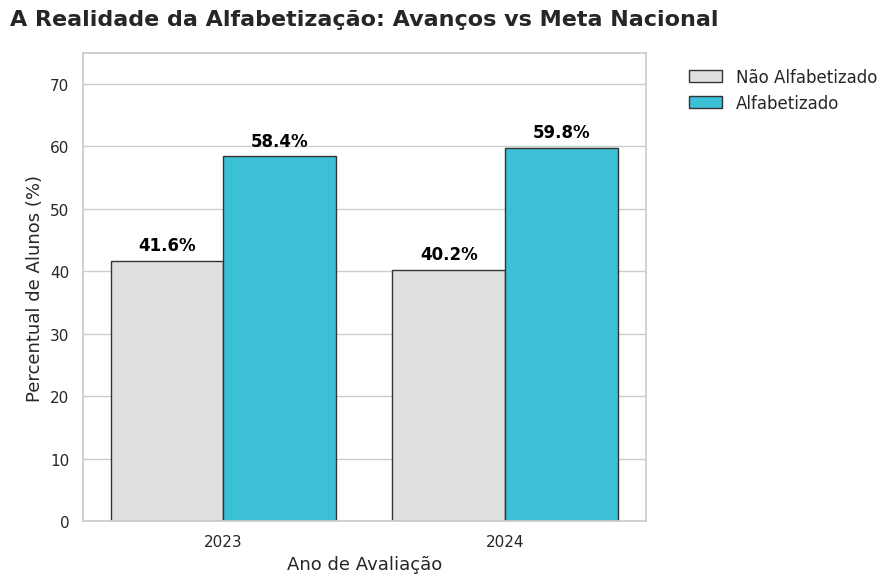

'\n**Resposta à Pergunta 1:**\nEmbora o Brasil apresente uma tendência positiva — com a taxa de alfabetizados subindo de 58,4% (2023) para 59,8% (2024) —, os dados revelam que **o país não atingiu a meta projetada de 60%** do Compromisso Nacional Criança Alfabetizada para 2024.\n\nIsso justifica a urgência da nossa solução de inteligência preditiva. Se não mudarmos a abordagem para algo proativo (como prever o risco municipal com antecedência), as metas futuras (rumo aos 100% em 2030) não serão atingidas.\n'

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Dados agregados (Cálculo que fizemos anteriormente, transformados em df para o plot)
dados_grafico = pd.DataFrame({
    'ano_str': ['2023', '2023', '2024', '2024'],
    'status': ['Não Alfabetizado', 'Alfabetizado', 'Não Alfabetizado', 'Alfabetizado'],
    'porcentagem': [41.6, 58.4, 40.2, 59.8] # Usando os dados da nossa base de alunos
})

# Meta estabelecida pelo MEC/Compromisso para 2024
meta_nacional_2024 = 60.0

# 2. Configuração do Gráfico
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

# Paleta de cores: um tom frio para 'Não Alfabetizado' e um tom de destaque para 'Alfabetizado'
ax = sns.barplot(
    data=dados_grafico,
    x='ano_str',
    y='porcentagem',
    hue='status',
    palette=['#e0e0e0', '#22d3ee'], # Cinza e Ciano (Alinhado com tech/dashboards)
    edgecolor='.2'
)



# 4. Adicionando os Rótulos
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=12, color='black', fontweight='bold',
            xytext=(0, 5), textcoords='offset points'
        )

# 5. Ajustes Finais e Títulos
plt.title('A Realidade da Alfabetização: Avanços vs Meta Nacional', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Ano de Avaliação', fontsize=13)
plt.ylabel('Percentual de Alunos (%)', fontsize=13)
plt.ylim(0, 75)
plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, fontsize=12)
plt.tight_layout()

# Exibir
plt.show()

# ---------------------------------------------------------
# CÉLULA MARKDOWN PARA O NOTEBOOK (STORYTELLING)
# ---------------------------------------------------------
"""
**Resposta à Pergunta 1:**
Embora o Brasil apresente uma tendência positiva — com a taxa de alfabetizados subindo de 58,4% (2023) para 59,8% (2024) —, os dados revelam que **o país não atingiu a meta projetada de 60%** do Compromisso Nacional Criança Alfabetizada para 2024.

Isso justifica a urgência da nossa solução de inteligência preditiva. Se não mudarmos a abordagem para algo proativo (como prever o risco municipal com antecedência), as metas futuras (rumo aos 100% em 2030) não serão atingidas.
"""

Pergunta 2 (A Disparidade Regional - Visão Estadual / UF)

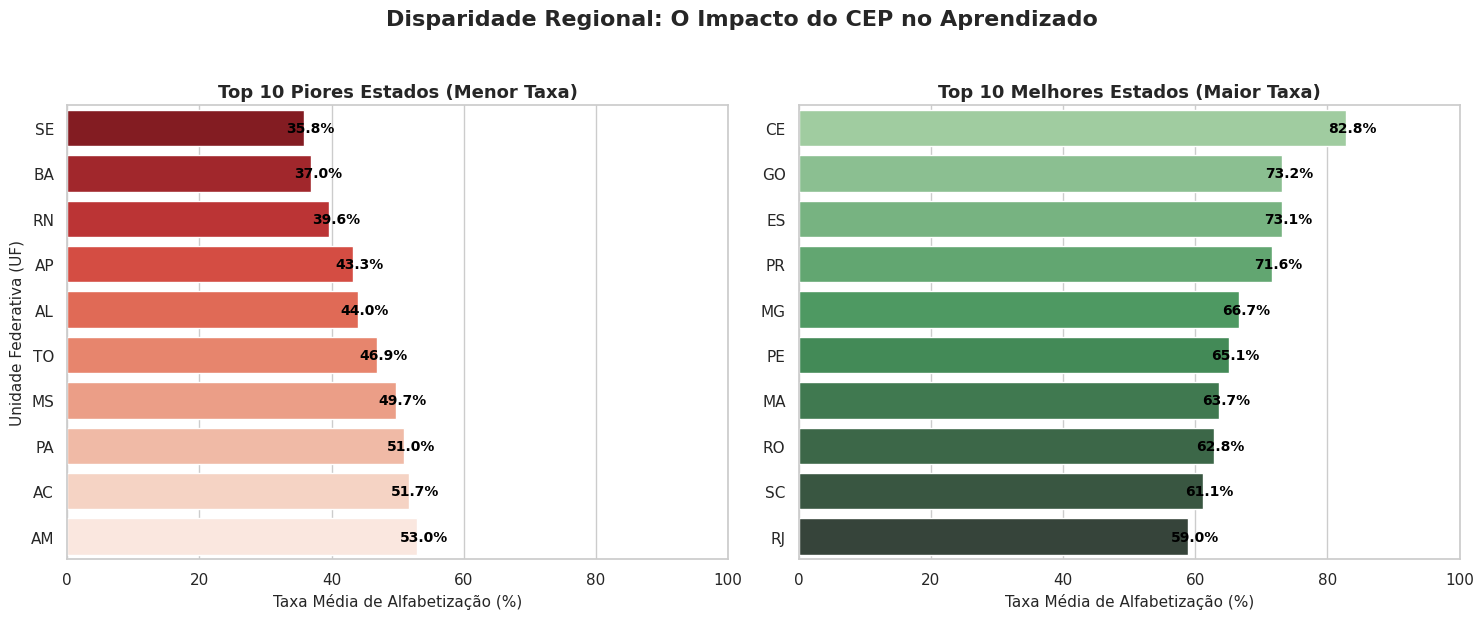

'\n**Resposta à Pergunta 2:**\nOs dados estaduais comprovam uma profunda assimetria no cenário educacional brasileiro. Enquanto os estados do topo da lista ultrapassam taxas expressivas de alfabetização, os 10 piores estados concentram um déficit educacional alarmante.\n\nIsso valida nossa hipótese inicial de que o fator geográfico e a infraestrutura local ditam as regras do aprendizado infantil, evidenciando a necessidade de políticas públicas regionalizadas e direcionadas.\n'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carrega a tabela de UF salva na pasta data/
df_uf_analise = pd.read_parquet("data/uf.parquet")

# 2. Agrupa por Estado (sigla_uf) calculando a média da taxa de alfabetização geral (2023-2024)
ranking_estados = df_uf_analise.groupby('sigla_uf')['taxa_alfabetizacao'].mean().reset_index()

# 3. Ordena para obter os 10 piores e os 10 melhores estados
top10_piores = ranking_estados.sort_values(by='taxa_alfabetizacao', ascending=True).head(10)
top10_melhores = ranking_estados.sort_values(by='taxa_alfabetizacao', ascending=False).head(10)

# 4. Configuração da Figura (Dois gráficos lado a lado)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.set_theme(style="whitegrid")

# Gráfico 1: Top 10 Piores Estados (Alerta de Risco)
sns.barplot(
    data=top10_piores,
    x='taxa_alfabetizacao',
    y='sigla_uf',
    ax=axes[0],
    palette='Reds_r'
)
axes[0].set_title('Top 10 Piores Estados (Menor Taxa)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Taxa Média de Alfabetização (%)', fontsize=11)
axes[0].set_ylabel('Unidade Federativa (UF)', fontsize=11)
axes[0].set_xlim(0, 100)

# Adicionando os valores nas barras dos piores
for p in axes[0].patches:
    width = p.get_width()
    if width > 0:
        axes[0].annotate(f'{width:.1f}%', (width + 1, p.get_y() + p.get_height()/2.),
                         ha='center', va='center', fontsize=10, fontweight='bold', color='black')

# Gráfico 2: Top 10 Melhores Estados (Referência)
sns.barplot(
    data=top10_melhores,
    x='taxa_alfabetizacao',
    y='sigla_uf',
    ax=axes[1],
    palette='Greens_d'
)
axes[1].set_title('Top 10 Melhores Estados (Maior Taxa)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Taxa Média de Alfabetização (%)', fontsize=11)
axes[1].set_ylabel('')
axes[1].set_xlim(0, 100)

# Adicionando os valores nas barras dos melhores
for p in axes[1].patches:
    width = p.get_width()
    if width > 0:
        axes[1].annotate(f'{width:.1f}%', (width + 1, p.get_y() + p.get_height()/2.),
                         ha='center', va='center', fontsize=10, fontweight='bold', color='black')

plt.suptitle('Disparidade Regional: O Impacto do CEP no Aprendizado', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# CÉLULA MARKDOWN PARA O NOTEBOOK (STORYTELLING)
# ---------------------------------------------------------
"""
**Resposta à Pergunta 2:**
Os dados estaduais comprovam uma profunda assimetria no cenário educacional brasileiro. Enquanto os estados do topo da lista ultrapassam taxas expressivas de alfabetização, os 10 piores estados concentram um déficit educacional alarmante.

Isso valida nossa hipótese inicial de que o fator geográfico e a infraestrutura local ditam as regras do aprendizado infantil, evidenciando a necessidade de políticas públicas regionalizadas e direcionadas.
"""

Pergunta 3

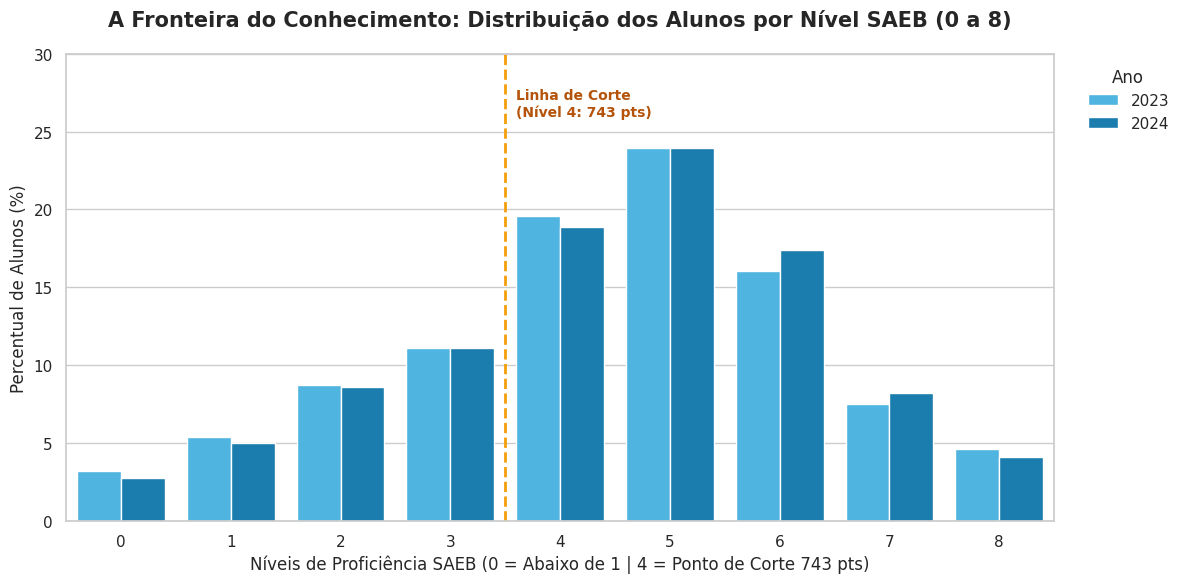

'\n**Resposta à Pergunta 3:**\nA distribuição dos alunos pelos níveis da escala SAEB revela que o maior gargalo educacional se concentra nos níveis intermediários (Níveis 3 e 4).\n\nO Nível 4 marca exatamente o ponto de corte regulatório de 743 pontos estabelecido pelo Inep. Identificar o volume expressivo de estudantes que flutuam na margem de transição (Nível 3) demonstra que pequenas intervenções pedagógicas direcionadas a esse grupo geram um impacto exponencial no indicador geral de alfabetização do país.\n'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupando e contando os alunos por nível de proficiência e ano
# (Utilizando o DataFrame df_modelo que criamos nas etapas anteriores)
df_niveis_dist = (
    df_modelo.groupby(['ano', 'nivel_proficiencia'])
    .size()
    .reset_index(name='quantidade')
)

# Calculando a porcentagem por ano para normalizar a visualização
total_por_ano = df_niveis_dist.groupby('ano')['quantidade'].transform('sum')
df_niveis_dist['porcentagem'] = (df_niveis_dist['quantidade'] / total_por_ano) * 100

# Convertendo o ano para string para melhorar a legenda do gráfico
df_niveis_dist['ano_str'] = df_modelo['ano'].astype(str) if 'ano' in df_modelo.columns else df_niveis_dist['ano'].astype(str)

# 2. Configuração do Gráfico de Distribuição por Níveis SAEB
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_niveis_dist,
    x='nivel_proficiencia',
    y='porcentagem',
    hue='ano',
    palette=['#38bdf8', '#0284c7'] # Tons de azul tecnológico
)

# 3. Customizações e Rótulos
plt.title('A Fronteira do Conhecimento: Distribuição dos Alunos por Nível SAEB (0 a 8)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Níveis de Proficiência SAEB (0 = Abaixo de 1 | 4 = Ponto de Corte 743 pts)', fontsize=12)
plt.ylabel('Percentual de Alunos (%)', fontsize=12)
plt.ylim(0, 30)

# Destacando visualmente o Nível 4 (Linha de corte de alfabetização)
# Você pode usar uma linha vertical tracejada para indicar onde fica o corte
plt.axvline(x=3.5, color='#f59e0b', linestyle='--', linewidth=2)
plt.text(3.6, 26, 'Linha de Corte\n(Nível 4: 743 pts)', color='#b45309', fontweight='bold', fontsize=10)

plt.legend(title='Ano', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# CÉLULA MARKDOWN PARA O NOTEBOOK (STORYTELLING)
# ---------------------------------------------------------
"""
**Resposta à Pergunta 3:**
A distribuição dos alunos pelos níveis da escala SAEB revela que o maior gargalo educacional se concentra nos níveis intermediários (Níveis 3 e 4).

O Nível 4 marca exatamente o ponto de corte regulatório de 743 pontos estabelecido pelo Inep. Identificar o volume expressivo de estudantes que flutuam na margem de transição (Nível 3) demonstra que pequenas intervenções pedagógicas direcionadas a esse grupo geram um impacto exponencial no indicador geral de alfabetização do país.
"""

In [ ]:
import pandas as pd
from IPython.display import display, HTML

# 1. Carrega as bases
df_mun_analise = pd.read_parquet("data/municipio.parquet")
df_regioes = pd.read_excel("Nome_Municipio_UF_com_regiao.xlsx")

# 2. Padronização rigorosa dos IDs
df_mun_analise['id_limpo'] = df_mun_analise['id_municipio'].astype(str).str.split('.').str[0].str.strip()
df_regioes['id_limpo'] = df_regioes['Código do Município'].astype(str).str.split('.').str[0].str.strip()

# 3. Merge para trazer a Sigla da UF e o Nome do Município
df_completo = df_mun_analise.merge(
    df_regioes[['id_limpo', 'Sigla da UF', 'Nome do Município']],
    on='id_limpo',
    how='left'
)

# 4. Filtra apenas os estados em alerta
estados_alvo = ['BA', 'RN', 'SE']
df_filtrado = df_completo[df_completo['Sigla da UF'].isin(estados_alvo)].copy()

# 5. REMOVE DUPLICADAS: Garante que cada município apareça apenas uma vez por estado
df_filtrado = df_filtrado.drop_duplicates(subset=['Sigla da UF', 'Nome do Município'])

# 6. Ordena do menor para o maior e pega exatamente os 3 piores DIFERENTES por UF
top3_distintos = (
    df_filtrado.sort_values(by=['Sigla da UF', 'taxa_alfabetizacao'], ascending=[True, True])
    .groupby('Sigla da UF')
    .head(3)
)

# 7. Formata e exibe como tabela HTML limpa no Colab
tabela_final = (
    top3_distintos[['Sigla da UF', 'Nome do Município', 'id_limpo', 'taxa_alfabetizacao']]
    .rename(columns={
        'Sigla da UF': 'UF',
        'Nome do Município': 'Município',
        'id_limpo': 'Código IBGE',
        'taxa_alfabetizacao': 'Taxa de Alfabetização (%)'
    })
)

display(HTML(tabela_final.to_html(index=False, classes='table table-striped')))

UF,Município,Código IBGE,Taxa de Alfabetização (%)
BA,Macururé,2919900,4.65
BA,Pau Brasil,2923902,9.26
BA,Catolândia,2907400,10.48
RN,Lucrécia,2406908,4.35
RN,Poço Branco,2410108,10.40
RN,Lagoa d'Anta,2406205,13.11
SE,Muribeca,2804300,10.00
SE,Riachuelo,2805901,11.32
SE,Pedrinhas,2805109,14.81


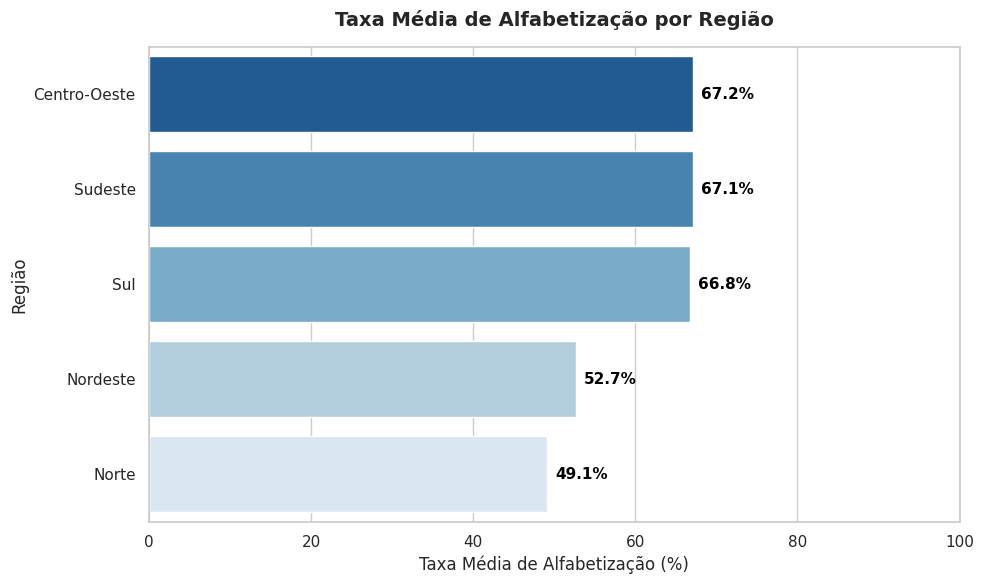

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carrega as bases
df_mun_analise = pd.read_parquet("data/municipio.parquet")
df_regioes = pd.read_excel("Nome_Municipio_UF_com_regiao.xlsx")

# 2. Padroniza as chaves
df_mun_analise['id_limpo'] = df_mun_analise['id_municipio'].astype(str).str.split('.').str[0].str.strip()
df_regioes['id_limpo'] = df_regioes['Código do Município'].astype(str).str.split('.').str[0].str.strip()

# 3. Merge para trazer a coluna de região
df_com_regiao = df_mun_analise.merge(
    df_regioes[['id_limpo', 'Nome do Município', 'Região']],
    on='id_limpo',
    how='left'
)

# 4. Agrupamento por Região calculando a média e ordenando de forma decrescente
taxa_por_regiao = (
    df_com_regiao.groupby('Região')['taxa_alfabetizacao']
    .mean()
    .reset_index(name='taxa_media_alfabetizacao')
    .sort_values(by='taxa_media_alfabetizacao', ascending=False)
)

# 5. Configuração e Plotagem do Gráfico de Barras Horizontais
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=taxa_por_regiao,
    x='taxa_media_alfabetizacao',
    y='Região',
    palette='Blues_r'
)

plt.title('Taxa Média de Alfabetização por Região', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Taxa Média de Alfabetização (%)', fontsize=12)
plt.ylabel('Região', fontsize=12)
plt.xlim(0, 100)

# Adicionando os valores percentuais nas pontas das barras
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width:.1f}%', (width + 1, p.get_y() + p.get_height()/2.),
                    ha='left', va='center', fontsize=11, fontweight='bold', color='black')

plt.tight_layout()
plt.show()